In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv(r"https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv", parse_dates=['Month'],
index_col='Month')
df.rename(columns={'Passengers':'Passengers'}, inplace=True)
print("Data Head:\n", df.head())

Data Head:
             Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [4]:
quarterly = df.resample('QE').mean()

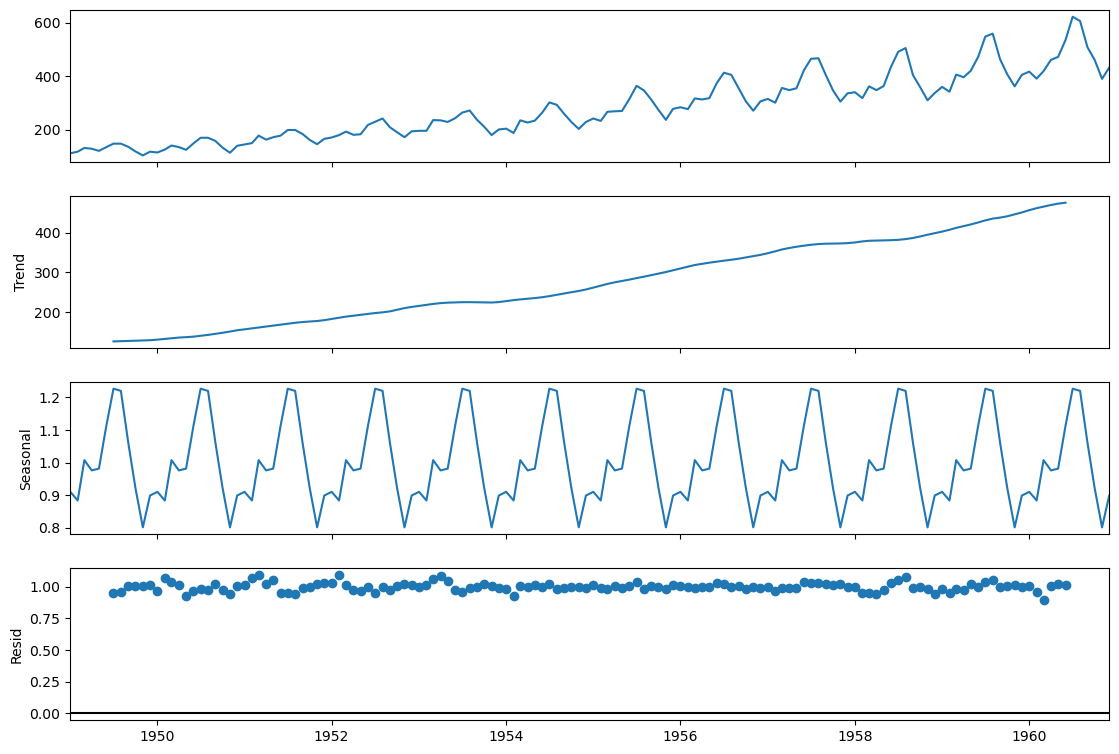

In [5]:
decomposition = seasonal_decompose(df, model='multiplicative')
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

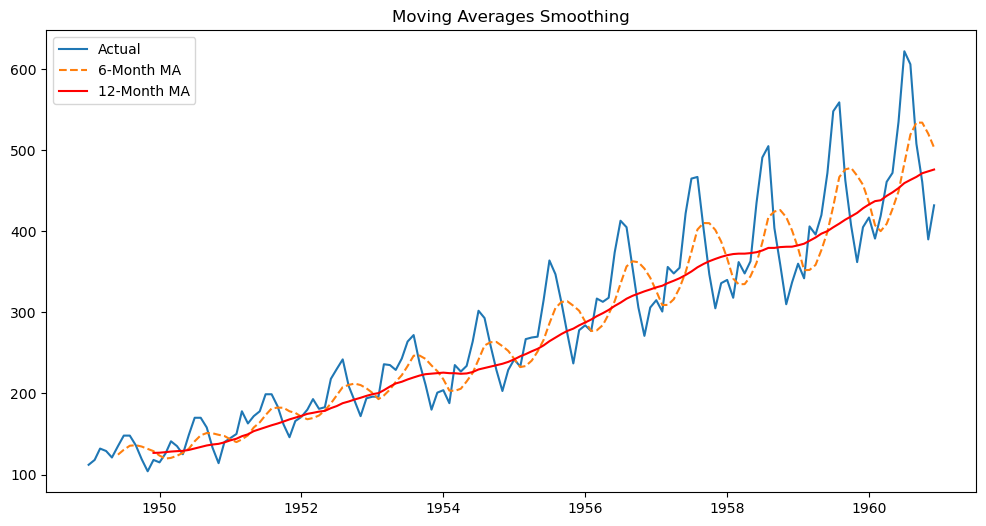

In [12]:
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Actual')
plt.plot(df['MA_6'], label='6-Month MA', linestyle='--')
plt.plot(df['MA_12'], label='12-Month MA', color='red')
plt.legend(); plt.title('Moving Averages Smoothing');

C:\Users\radha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\radha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\radha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\radha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\radha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

RMSE: 21.2 passengers


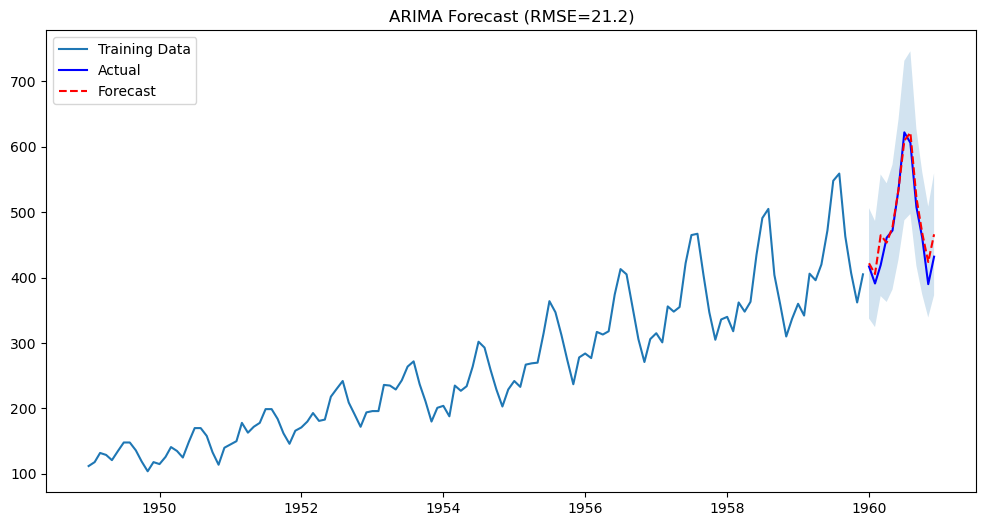

In [17]:
train = df['Passengers'].iloc[:-12]
test = df['Passengers'].iloc[-12:]
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt 

model = auto_arima(train, seasonal=True, m=12)
model = ARIMA(train, order=(2,1,1), seasonal_order=(1,1,1,12))
result = model.fit()
forecast = result.forecast(steps=12)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse:.1f} passengers")

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, forecast*0.8, forecast*1.2, alpha=0.2)
plt.title(f"ARIMA Forecast (RMSE={rmse:.1f})")
plt.legend()
plt.show() 